### Задание:
**Задача 1**
Изучите таблицу users_info, содержащую информацию о пользователях. Проведите разведочный анализ данных:

**Общая информация о таблице**
+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

**Пропущенные значения**
+Сколько пропущенных значений в каждом столбце?
+ Удалите все строки с пропущенными значениями. Какой процент данных был удалён?

**Выбросы по возрасту**
+ Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
+ Удалите выбросы из таблицы.

**Визуализация**
+ Постройте гистограмму (sns.histplot) распределения возрастов пользователей.



**Задача 2** 
Проанализируйте распределение пользователей по полу и городам:
+ Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

+ Используйте pivot_table, чтобы представить данные:
— города в строках,
— пол в столбцах.
+ Для каждого города рассчитайте долю женщин среди всех пользователей.
+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

**Подсказка:** для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы. 
+ Разделите пользователей на три группы по уровню активности:

— мало (редко тренируются),

— средне,

— много (тренируются часто).

+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [4]:
users_info.shape # проверяем сколько в таблице строк и столбцов

(1000, 4)

In [5]:
users_info.dtypes # проверяем типы данных каждого столбца

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [6]:
users_info.isnull().sum() # находим ко-во пропущенных значений в каждом столбце

id_user     0
city        0
age        88
gender     89
dtype: int64

In [7]:
users_info.loc[users_info['gender'].isnull()]

,id_user,city,age,gender
3,1003,Москва,NaN,NaN
63,1063,СПб,NaN,NaN
69,1069,Москва,NaN,NaN
91,1091,СПб,NaN,NaN
95,1095,Москва,64.0,NaN
...,...,...,...,...
952,1952,Казань,45.0,NaN
966,1966,Москва,NaN,NaN
991,1991,Москва,19.0,NaN
996,1996,Москва,34.0,NaN


In [8]:
clean_users = users_info.dropna() # удаляем пропущенные значения

In [9]:
clean_users.isnull().sum() 

id_user    0
city       0
age        0
gender     0
dtype: int64

In [10]:
clean_users.shape # проверяем сколько строк осталось 

(865, 4)

In [11]:
print(f'Процент пропущенных значений равен: {(1000-865)/1000*100} %') # находим % пропущенных значений

Процент пропущенных значений равен: 13.5 %


<Axes: ylabel='age'>

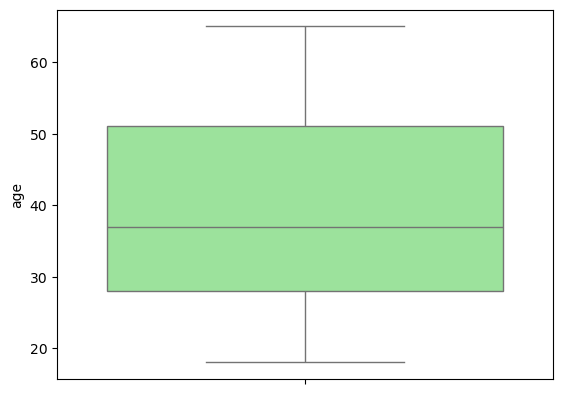

In [12]:
sns.boxplot(clean_users['age'], color = 'lightgreen')

In [13]:
# определяем границы для выбросов в колонке age с помощью метода IQR 
Q1 = np.percentile(clean_users['age'], 25)
Q3 = np.percentile(clean_users['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
print(lower_bound)
print(upper_bound)

-6.5
85.5


In [14]:
clean_users['age'].describe() # max значение в столбце 'age' равно 65, min значение равно 18, т.е. значения не выходят за границы выбросов

count    865.000000
mean      39.419653
std       13.774501
min       18.000000
25%       28.000000
50%       37.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

In [15]:
users_clean = clean_users.loc[clean_users['age'] < upper_bound].copy()
users_clean.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
4,1004,Екатеринбург,60.0,male
5,1005,СПб,35.0,female


In [16]:
users_clean.shape

(865, 4)

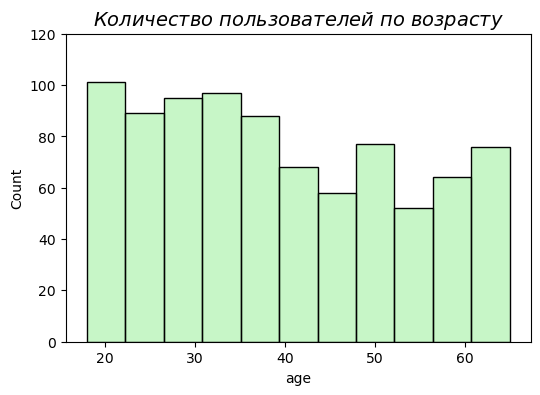

In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(users_clean['age'], color = 'lightgreen', alpha = .5)
plt.title('$Количество$ $пользователей$ $по$ $возрасту$', fontsize = 14)
plt.ylim(0, 120)
plt.show()

### Задача 2. Доля пользователей-женщин по городам

In [18]:
# Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.
# Используйте pivot_table, чтобы представить данные: — города в строках, — пол в столбцах.
# Для каждого города рассчитайте долю женщин среди всех пользователей.
# Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

In [19]:
users_clean['gender'].value_counts(normalize = True)

gender
female    0.521387
male      0.478613
Name: proportion, dtype: float64

In [20]:
# определяем для каждого города и пола количество пользователей 
cnt_city_gender = users_clean.groupby(['city', 'gender'])['id_user'].count().reset_index()

cnt_city_gender.head()

,city,gender,id_user
0,Екатеринбург,female,55
1,Екатеринбург,male,78
2,Казань,female,53
3,Казань,male,77
4,Москва,female,220


In [21]:
# определяем количество пользователей через сводную таблицу, где строки - это города, а пол - это столбцы  
pivot_users = users_clean.pivot_table(values = 'id_user',\
                          index = 'city',\
                          columns = 'gender',\
                          aggfunc = 'count', fill_value = 0).reset_index()

pivot_users.columns = ['city', 'cnt_female', 'cnt_male'] # корректируем название столбцов 
pivot_users['cnt_all'] = pivot_users['cnt_female'] + pivot_users['cnt_male'] # добавляем столбец с общим кол-ом пользователей в городе
pivot_users['share_female'] = pivot_users['cnt_female']/pivot_users['cnt_all']  # добавляем столбец с долей женщин

pivot_users.head()

,city,cnt_female,cnt_male,cnt_all,share_female
0,Екатеринбург,55,78,133,0.413534
1,Казань,53,77,130,0.407692
2,Москва,220,105,325,0.676923
3,СПб,123,154,277,0.444043


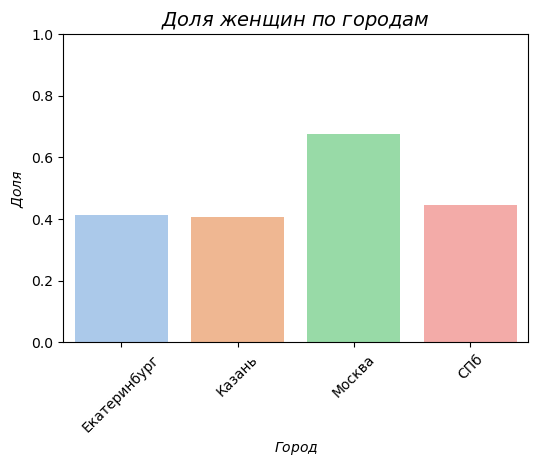

In [22]:
# строим столбчатую диаграмму для доли женщин по городам
plt.figure(figsize=(6, 4))
sns.barplot(pivot_users, x='city', y='share_female', hue='city', palette='pastel', legend = False)

plt.title('$Доля$ $женщин$ $по$ $городам$', fontsize = 14)
plt.xlabel('$Город$', fontsize = 10)
plt.ylabel('$Доля$', fontsize = 10)
plt.ylim(0, 1.0)
plt.xticks(rotation = 45)

plt.show()

In [23]:
print(f'Наибольшая доля женщин в городе {pivot_users.loc[pivot_users['share_female'].idxmax(),'city']} ({pivot_users['share_female'].max():.2%})')

Наибольшая доля женщин в городе Москва (67.69%)


### Задача 3. Делим пользователей на бины

In [24]:
# Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.
# Рассчитайте среднее количество тренировок в месяц для каждого пользователя.
# Подсказка: для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы.
# Разделите пользователей на три группы по уровню активности: мало (редко тренируются), средне, много (тренируются часто).
# Посчитайте, сколько пользователей входит в каждую из этих групп.

In [25]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [26]:
# рассчитаем среднее количество тренировок в месяц для каждого пользователя
avg_cnt_mon = pay_mon.groupby('id_user').agg(avg_cnt_mon = ('cnt_total', 'mean')).round(0).reset_index()
avg_cnt_mon.head()

,id_user,avg_cnt_mon
0,1000,4.0
1,1001,12.0
2,1002,12.0
3,1003,5.0
4,1004,2.0


In [27]:
# исходя из количества тренировок в месяц разбиваем пользователей на группы
bins = [0, 8, 12, float('inf')] # задаем границы групп
labels = ['низкий', 'средний', 'высокий'] # задаем название групп
avg_cnt_mon['group'] = pd.cut(avg_cnt_mon['avg_cnt_mon'], bins=bins, labels=labels, right=True) # создаем новый столбец с указанием группы
avg_cnt_mon.head()

,id_user,avg_cnt_mon,group
0,1000,4.0,низкий
1,1001,12.0,средний
2,1002,12.0,средний
3,1003,5.0,низкий
4,1004,2.0,низкий


In [28]:
# считаем количество пользователей в группах активности
cnt_user_bin = avg_cnt_mon.groupby('group', observed = False).agg(cnt_user = ('id_user', 'count')).reset_index()
cnt_user_bin['share'] = round(cnt_user_bin['cnt_user']/cnt_user_bin['cnt_user'].sum(), 2)

cnt_user_bin.head()

,group,cnt_user,share
0,низкий,719,0.74
1,средний,198,0.20
2,высокий,52,0.05


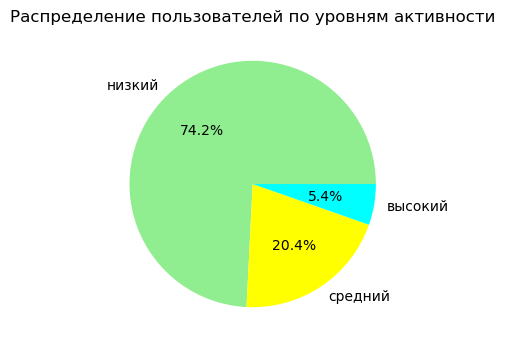

In [29]:
# для наглядности построим пайчарт 
plt.figure(figsize=(6, 4))
plt.pie(cnt_user_bin['cnt_user'], labels=cnt_user_bin['group'], autopct='%1.1f%%', colors=['lightgreen', 'yellow', 'cyan'])
plt.title('Распределение пользователей по уровням активности')

plt.show()